In [2]:
import numpy as np
import xarray as xr
import pandas as pd
from scipy.stats import moment
import matplotlib.colors as mcolors
from matplotlib.ticker import MultipleLocator, AutoMinorLocator



import matplotlib.pyplot as plt
import calendar
import matplotlib.patches as mpatches
import seaborn as sns

from pylab import rcParams
rcParams['axes.labelweight'] = 'bold'
rcParams['axes.labelsize'] = 'x-large'
rcParams['axes.titlesize'] = 'xx-large'
rcParams['axes.titleweight'] = 'bold'

In [3]:
# functions to import data

In [4]:
def decode_time(filepath):
    ds = xr.open_dataset(filepath, decode_times=False)
    units, reference_date = ds.time.attrs['units'].split('since')
    ds['time'] = pd.date_range(start=reference_date, periods=ds.sizes['time'], freq='MS')
    return ds

In [5]:
# functions to analyse

In [6]:
def calculate_deciles(data):
    # Flatten the data to 1D array for qcut
    flattened_data = data.flatten()
    # Calculate deciles using qcut
    deciles, bins = pd.qcut(flattened_data, qs, labels=False, retbins=True)
    # Reshape the result back to the original data shape
    return deciles.reshape(data.shape)

def calculate_monthly_deciles(ds, variable_name):
    # Get the shape of the data
    n_months = ds['time'].size
    lat_size = ds['lat'].size
    lon_size = ds['lon'].size
    
    # Create an empty array to hold the decile values
    deciles_array = np.empty((n_months, lat_size, lon_size))
    
    # Loop through each month and calculate deciles
    for i in range(n_months):
        month_data = ds[variable_name].isel(time=i).values
        deciles_array[i, :, :] = calculate_deciles(month_data)
    
    # Create a new DataArray for deciles
    dec = xr.DataArray(
        deciles_array,
        coords=[ds['time'], ds['lat'], ds['lon']],
        dims=['time', 'lat', 'lon']
    )
    
    return dec

In [7]:
def calculate_quantiles(data):
    # Flatten the data to 1D array for qcut
    flattened_data = data.flatten()
    # Calculate deciles using qcut
    deciles, bins = pd.qcut(flattened_data, qs, labels=False, retbins=True)
    # Reshape the result back to the original data shape
    return deciles.reshape(data.shape)


In [8]:
# Define constants
p0 = 1000  # reference pressure in hPa
R = 287.05  # specific gas constant for dry air in J/(kg*K)
cp = 1005  # specific heat at constant pressure for dry air in J/(kg*K)

def convert_to_potential_temperature(T, p):
    """
    Convert temperature to potential temperature.
    
    Parameters:
    T (xarray.DataArray): Temperature in K
    p (xarray.DataArray): Pressure in hPa
    
    Returns:
    xarray.DataArray: Potential temperature in K
    """
    return T * (p0 / p) ** (R / cp)

In [9]:
qs = 20

# Ocean Mask

In [10]:
#load the masks
fp = '/data/jmex/masks/RECCAP2_region_masks_all.nc'
masks = xr.open_dataset(fp).sel(lat = slice(-15,25))
ocean_mask = masks.open_ocean.isin([2,3]) # mask for tropical indo-pacifi

# TP 

In [11]:
fp = '/data/jmex/NOAA//latest/precip.mon.mean.nc'
tp = xr.open_dataset(fp).sel(lat = slice(-15,25), time = slice(None,None))
tp = tp.drop_vars(['time_bnds', 'lat_bnds', 'lon_bnds']).rename({'precip':'tp'})


# ERA5



In [12]:
fp = '/data/jmex/ERA5/monthly/era5_sst.nc'
sst = decode_time(fp).sel(lat = slice(25,-15), time = slice('1979', '2023'))

sst = sst.where(ocean_mask)

#ocean_mask = ~sst.isel(time = 1).sst.isnull() # this mask for all tropics

In [13]:
fp = '/data/jmex/ERA5/monthly/era5_sst24.nc'
sst24 = xr.open_dataset(fp).sel(latitude = (slice(25, -15)))


#change the longitude defintion to 0-360
sst24 = sst24.rename({'latitude':'lat', 'longitude':'lon'})
sst24 = sst24.drop_vars(['number', 'expver'])


sst24 = sst24.rename({'date':'time'})
sst24['time'] = pd.to_datetime(sst24['time'].values.astype(str), format='%Y%m%d')

sst24 = sst24.where(ocean_mask)

In [14]:
sst = xr.concat([sst, sst24], dim = 'time')



In [15]:
#interpolate to tp grid
sst = sst.interp(lat = tp.lat, lon = tp.lon, method = 'nearest')
#make new ocean mask to subselect tp field
ocean_mask2 = ~sst.isel(time = 1).sst.isnull()

#3-month rolling mean of sst
sst = sst.rolling(time = 3, center = True, min_periods = 1,).mean()

In [16]:
# compute quantiles of sst clim

In [17]:
sst_clim = sst.sel(time = slice('1991', '2020')).groupby('time.month').mean()
sst['anom'] = sst.sst.groupby('time.month') - sst_clim.sst

In [18]:
sst = sst.rolling(time = 3, center = True, min_periods = 1,).mean()

In [19]:
# calculate quantile of data on the climatology
qs = 20
sst_qs = calculate_quantiles(sst_clim.sst.values)





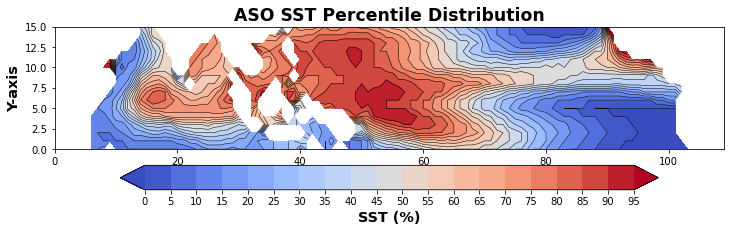

In [20]:
sst_aso_qs= np.mean(sst_qs[8:10,:,10:120], axis = 0)*5

# Define discrete color levels
levels = np.arange(0, 100, 5)  # Levels from 0 to 20

# Create the plot
fig, ax = plt.subplots(figsize = (12,3))
cbar = ax.contourf(sst_aso_qs, levels=levels, cmap='coolwarm', extend='both')
contours = ax.contour(sst_aso_qs, levels=levels, colors='black', linewidths=0.5)
#plt.clabel(contours, inline=False, fontsize=8)

# Add a horizontal discrete colorbar
cbar_ax = fig.colorbar(cbar, ax=ax, orientation='horizontal', ticks=levels, pad=0.1)
cbar_ax.set_label('SST (%)')

plt.title('ASO SST Percentile Distribution')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')

plt.show()

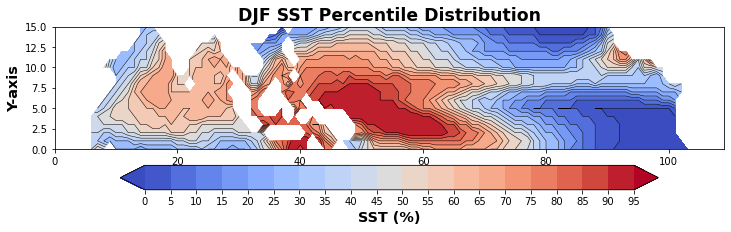

In [21]:
sst_aso_qs= np.mean(sst_qs[11:13,:,10:120], axis = 0)*5

# Define discrete color levels
levels = np.arange(0, 100, 5)  # Levels from 0 to 20

# Create the plot
fig, ax = plt.subplots(figsize = (12,3))
cbar = ax.contourf(sst_aso_qs, levels=levels, cmap='coolwarm', extend='both')
contours = ax.contour(sst_aso_qs, levels=levels, colors='black', linewidths=0.5)
#plt.clabel(contours, inline=False, fontsize=8)

# Add a horizontal discrete colorbar
cbar_ax = fig.colorbar(cbar, ax=ax, orientation='horizontal', ticks=levels, pad=0.1)
cbar_ax.set_label('SST (%)')

plt.title('DJF SST Percentile Distribution')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')

plt.show()

# TP

In [22]:
#subselect tp field
tp = tp.where(ocean_mask2)

In [23]:
tp = tp.rolling(time = 3, center = True, min_periods = 1,).mean()

In [24]:
tp_clim = tp.sel(time = slice('1991', '2020')).groupby('time.month').mean()
tp['anom'] = tp.tp.groupby('time.month') - tp_clim.tp

In [25]:
weights = np.cos(np.deg2rad(tp.lat))
tp['ocean_mean'] = tp.anom.weighted(weights).mean(['lat', 'lon'])

In [26]:
tp_sel = tp.sel(time = slice('2022-07', '2024-06'))
tp_by_qs = np.zeros((qs, tp_sel.time.shape[0]))

for it in range(len(tp_sel.time)):
    month_id = (it+7)%12
    s = tp_sel.isel(time = it).anom.values
    
    #loop thorgh each quantile
    for iq in range(qs):

        tp_by_qs[iq, it] = np.nanmean(s[sst_qs[month_id] == iq])#- tp_sel.isel(time = it).ocean_mean

In [27]:
def compute_tp_by_quantiles(tp, sst_qs, qs, start_time, end_time):
    """
    Compute `tp` values based on SST quantiles for a given time slice.

    Parameters:
    - tp: xarray DataArray containing the `tp` data.
    - sst_qs: quantile-based segmentation array derived from SST.
    - qs: number of quantiles.
    - start_time: str, start of the time slice (e.g., '2014-07').
    - end_time: str, end of the time slice (e.g., '2016-06').

    Returns:
    - tp_by_qs: 2D numpy array of shape (qs, time_length), the processed `tp` values.
    """
    tp_sel = tp.sel(time=slice(start_time, end_time))
    time_length = len(tp_sel.time)
    tp_by_qs = np.zeros((qs, time_length))

    for it in range(time_length):
        month_id = (it + 7) % 12  # Offset month ID
        s = tp_sel.isel(time=it).anom.values

        for iq in range(qs):
            tp_by_qs[iq, it] = (
                np.nanmean(s[sst_qs[month_id] == iq]))# - tp_sel.isel(time=it).ocean_mean)

    return tp_by_qs

def aggregate_tp_by_quantiles(tp, sst_qs, qs, time_periods):
    """
    Aggregate `tp` quantile computations over multiple time periods.

    Parameters:
    - tp: xarray DataArray containing the `tp` data.
    - sst_qs: quantile-based segmentation array derived from SST.
    - qs: number of quantiles.
    - time_periods: list of tuples, each with (start_time, end_time).

    Returns:
    - aggregated_tp_by_qs: 2D numpy array of the mean `tp` values across all periods.
    """
    all_tp_by_qs = []
    
    for start_time, end_time in time_periods:
        tp_by_qs = compute_tp_by_quantiles(tp, sst_qs, qs, start_time, end_time)
        all_tp_by_qs.append(tp_by_qs)
    
    aggregated_tp_by_qs = np.mean(all_tp_by_qs, axis=0)
    return aggregated_tp_by_qs


In [28]:
# Define your time periods
tp_time_periods = [
    ('1990-07', '1992-06'),
    ('1986-07', '1988-06'),
    ('1981-07', '1983-06'),
    ('1996-07', '1998-06'),
    ('2008-07', '2010-06'),
    ('2014-07', '2016-06'),
    # Add more periods as needed
]

# Compute aggregated `tp` by quantiles
tp_by_qs_compound = aggregate_tp_by_quantiles(tp, sst_qs, qs, tp_time_periods)


In [29]:
#for making the mask: take all events
all_tp_by_qs = np.zeros((len(tp_time_periods), qs, 24))

i = 0
for start_time, end_time in tp_time_periods:
    temp_tp_by_qs = compute_tp_by_quantiles(tp, sst_qs, qs, start_time, end_time)
    all_tp_by_qs[i] = temp_tp_by_qs
    i+=1

## contours

In [30]:

#extend periodically to cover july to jun over 2 years
tp_clim_by_qs = np.zeros((qs, 24))

for it in range(24):
    month_id = (it+7)%12
    s = tp_clim.isel(month = month_id).tp.values
    
    #loop thorgh each quantile
    for iq in range(qs):

        tp_clim_by_qs[iq, it] = np.nanmean(s[sst_qs[month_id] == iq])
        


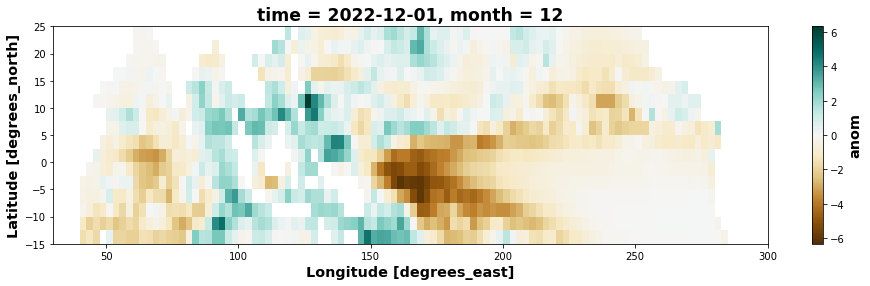

In [31]:
tp.sel(time = '2022-12', lon = slice(30, 300)).anom.plot(size = 4, aspect = 4, cmap = 'BrBG')

## comparison

In [32]:
comparison = tp_by_qs>all_tp_by_qs
mask_all_five_larger = comparison.all(axis = 0)
mask_at_least_four_larger = comparison.sum(axis = 0) >=4

comparison = tp_by_qs<all_tp_by_qs
mask_all_five_smaller = comparison.all(axis = 0)
mask_at_least_four_smaller = comparison.sum(axis = 0) >=4

In [33]:
tp_by_qs_diff = tp_by_qs - tp_by_qs_compound


# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))

# Display the data using imshow
img = ax.imshow(
    tp_by_qs, cmap='BrBG', vmin=-2., vmax=2.,
    interpolation='none', origin='lower',
    aspect = .8
)

# Add color bar with label
#cbar = plt.colorbar(img, ax=ax, pad=0.02, extend = 'both')
#cbar.set_label('TP Anomaly [mm/day]', fontsize=12)

# Set y-axis labels
yticks = np.linspace(0, tp_by_qs.shape[0] - 1, 5).astype(int)  # Adjust ticks for clarity
ylabels = np.linspace(0, 100, len(yticks)).astype(int)  # Percentile labels
ax.set_yticks(yticks)
ax.set_yticklabels(ylabels)
ax.set_ylabel('SST Percentile [%]', fontsize=12)

# Set x-axis labels
xticks = [0,3,6,9, 12,15, 18, 21]  # Adjust ticks for clarity
xlabels = ['Jul', 'Oct', 'Jan', 'Mai', 'Jul', 'Oct', 'Jan', 'Mai']  # Representative months
ax.set_xticks(xticks)
ax.set_xticklabels(xlabels)
ax.set_xlabel('Time', fontsize=12)

ax.axvline(6, linestyle = '--', c = 'k')
ax.axvline(18, linestyle = '--', c = 'k')

# Add a thick frame around the plot
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(2)

# Add title and format ticks
#ax.set_title('2023', fontsize=14, fontweight='bold')
ax.tick_params(axis='both', which='major', labelsize=10)

# Adjust layout for better fit
plt.tight_layout()

# Show the plot
plt.show()



# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))

# Display the data using imshow
img = ax.imshow(
    tp_by_qs_compound, cmap='BrBG', vmin=-2., vmax=2.,
    interpolation='none', origin='lower',
    aspect = .8
)

# Add color bar with label
#cbar = plt.colorbar(img, ax=ax, pad=0.02, extend = 'both')
#cbar.set_label('TP Anomaly [mm/day]', fontsize=12)

# Set y-axis labels
yticks = np.linspace(0, tp_by_qs.shape[0] - 1, 5).astype(int)  # Adjust ticks for clarity
ylabels = np.linspace(0, 100, len(yticks)).astype(int)  # Percentile labels
ax.set_yticks(yticks)
ax.set_yticklabels('')
ax.set_ylabel('', fontsize=12)

# Set x-axis labels
xticks = [0,3,6,9, 12,15, 18, 21]  # Adjust ticks for clarity
xlabels = ['Jul', 'Oct', 'Jan', 'Mai', 'Jul', 'Oct', 'Jan', 'Mai']  # Representative months
ax.set_xticks(xticks)
ax.set_xticklabels(xlabels)
ax.set_xlabel('Time', fontsize=12)

ax.axvline(6, linestyle = '--', c = 'k')
ax.axvline(18, linestyle = '--', c = 'k')

# Add a thick frame around the plot
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(2)

# Add title and format ticks
#ax.set_title('Compound', fontsize=14, fontweight='bold')
ax.tick_params(axis='both', which='major', labelsize=10)

# Adjust layout for better fit
plt.tight_layout()

# Show the plot
plt.show()



# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))

# Display the data using imshow
img = ax.imshow(
    tp_by_qs_diff, cmap='BrBG', vmin=-2., vmax=2.,
    interpolation='none', origin='lower',
    aspect = .8
)

# Add color bar with label
cbar = plt.colorbar(img, ax=ax, pad=0.02, extend = 'both')
cbar.set_label('TP Anomaly [mm/day]', fontsize=12)

# Set y-axis labels
yticks = np.linspace(0, tp_by_qs.shape[0] - 1, 5).astype(int)  # Adjust ticks for clarity
ylabels = np.linspace(0, 100, len(yticks)).astype(int)  # Percentile labels
ax.set_yticks(yticks)
ax.set_yticklabels('')
ax.set_ylabel('', fontsize=12)

# Set x-axis labels
xticks = [0,3,6,9, 12,15, 18, 21]  # Adjust ticks for clarity
xlabels = ['Jul', 'Oct', 'Jan', 'Mai', 'Jul', 'Oct', 'Jan', 'Mai']  # Representative months
ax.set_xticks(xticks)
ax.set_xticklabels(xlabels)
ax.set_xlabel('Time', fontsize=12)

ax.axvline(6, linestyle = '--', c = 'k')
ax.axvline(18, linestyle = '--', c = 'k')

# Add a thick frame around the plot
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(2)

# Add title and format ticks
ax.set_title('2023 - Compound', fontsize=14, fontweight='bold')
ax.tick_params(axis='both', which='major', labelsize=10)






#hatching
# Add diagonal hatching for significant regions
plt.contourf(
    mask_all_five_larger,  # Coordinates and mask
    levels=[0.5, 1.5],  # Define binary levels
    colors='none',  # No filled color
    hatches=['//'],  # Diagonal hatching
    extend='neither',
    alpha=0  # Fully transparent background, only hatching visible
)


# Add diagonal hatching for significant regions
plt.contourf(
    mask_at_least_four_larger,  # Coordinates and mask
    levels=[0.5, 1.5],  # Define binary levels
    colors='none',  # No filled color
    hatches=['\\'],  # Diagonal hatching
    extend='neither',
    alpha=0  # Fully transparent background, only hatching visible
)

# Add diagonal hatching for significant regions
plt.contourf(
    mask_all_five_smaller,  # Coordinates and mask
    levels=[0.5, 1.5],  # Define binary levels
    colors='none',  # No filled color
    hatches=['//'],  # Diagonal hatching
    extend='neither',
    alpha=0  # Fully transparent background, only hatching visible
)


# Add diagonal hatching for significant regions
plt.contourf(
    mask_at_least_four_smaller,  # Coordinates and mask
    levels=[0.5, 1.5],  # Define binary levels
    colors='none',  # No filled color
    hatches=['\\'],  # Diagonal hatching
    extend='neither',
    alpha=0  # Fully transparent background, only hatching visible
)


# Adjust layout for better fit
plt.tight_layout()

# Show the plot
plt.show()


## Make the sst plots with reduced events for compound

In [34]:
def compute_sst_by_quantiles(sst, start_time, end_time, sst_qs, qs):
    """
    Compute SST values based on quantiles for a given time slice.

    Parameters:
    - sst: xarray DataArray containing SST data.
    - start_time: str, start of the time slice (e.g., '1964-07').
    - end_time: str, end of the time slice (e.g., '1966-06').
    - sst_qs: quantile-based segmentation array.
    - qs: number of quantiles.

    Returns:
    - sst_by_qs: 2D numpy array of shape (qs, time_length), the processed SST values.
    """
    sst_sel = sst.sel(time=slice(start_time, end_time))
    time_length = len(sst_sel.time)
    sst_by_qs = np.zeros((qs, time_length))

    for it in range(time_length):
        month_id = (it + 7) % 12  # Offset month ID
        s = sst_sel.isel(time=it).anom.values

        for iq in range(qs):
            sst_by_qs[iq, it] = (
                np.nanmean(s[sst_qs[month_id] == iq]) - sst_sel.isel(time=it).ocean_mean
            )

    return sst_by_qs

def aggregate_sst_by_quantiles(sst, time_periods, sst_qs, qs):
    """
    Aggregate SST quantile computations over multiple time periods.

    Parameters:
    - sst: xarray DataArray containing SST data.
    - time_periods: list of tuples, each with (start_time, end_time).
    - sst_qs: quantile-based segmentation array.
    - qs: number of quantiles.

    Returns:
    - aggregated_sst_by_qs: 2D numpy array of the mean SST values across all periods.
    """
    all_sst_by_qs = []
    
    for start_time, end_time in time_periods:
        sst_by_qs = compute_sst_by_quantiles(sst, start_time, end_time, sst_qs, qs)
        all_sst_by_qs.append(sst_by_qs)
    
    aggregated_sst_by_qs = np.mean(all_sst_by_qs, axis=0)
    return aggregated_sst_by_qs

In [ ]:
fp = '/data/jmex/ERA5/monthly/era5_sst.nc'
sst = decode_time(fp).sel(lat = slice(25,-15), time = slice('1950', '2023'))

sst = sst.where(ocean_mask)


#ocean_mask = ~sst.isel(time = 1).sst.isnull() # this mask for all tropics

In [ ]:
fp = '/data/jmex/ERA5/monthly/era5_sst24.nc'
sst24 = xr.open_dataset(fp).sel(latitude = (slice(25, -15)))


#change the longitude defintion to 0-360

sst24 = sst24.rename({'latitude':'lat', 'longitude':'lon'})
sst24 = sst24.drop_vars(['number', 'expver'])


sst24 = sst24.rename({'date':'time'})
sst24['time'] = pd.to_datetime(sst24['time'].values.astype(str), format='%Y%m%d')

sst24 = sst24.where(ocean_mask)

In [ ]:
sst = xr.concat([sst, sst24], dim = 'time')
sst_clim = sst.sel(time = slice('1991', '2020')).groupby('time.month').mean()
sst['anom'] = sst.sst.groupby('time.month') - sst_clim.sst

sst = sst.rolling(time = 3, center = True, min_periods = 1,).mean()

In [ ]:
weights = np.cos(np.deg2rad(sst.lat))
sst['ocean_mean'] = sst.anom.weighted(weights).mean(['lat', 'lon'])

In [ ]:
# calculate quantile of data on the climatology
qs = 20
sst_qs = calculate_quantiles(sst_clim.sst.values)



In [ ]:
# Define your time periods
time_periods = [
     ('1990-07', '1992-06'),
    ('1986-07', '1988-06'),
    ('1981-07', '1983-06'),
    ('1996-07', '1998-06'),
    ('2008-07', '2010-06'),
    ('2014-07', '2016-06'),
    # Add more periods as needed
]

# Compute aggregated SST by quantiles
sst_by_qs_compound = aggregate_sst_by_quantiles(sst, time_periods, sst_qs, qs)


In [ ]:
#for making the mask: take all events
all_sst_by_qs = np.zeros((len(time_periods), qs, 24))

i = 0
for start_time, end_time in time_periods:
    sst_by_qs = compute_sst_by_quantiles(sst, start_time, end_time, sst_qs, qs)
    all_sst_by_qs[i] = sst_by_qs
    i+=1

In [ ]:
sst_sel = sst.sel(time = slice('2022-07', '2024-06'))
sst_by_qs = np.zeros((qs, 24))

for it in range(len(sst_sel.time)):
    month_id = (it+7)%12 
    s = sst_sel.isel(time = it).anom.values
    
    #loop thorgh each quantile
    for iq in range(qs):

        sst_by_qs[iq, it] = np.nanmean(s[sst_qs[month_id] == iq]) - sst_sel.isel(time = it).ocean_mean 
        #take away comment if want to subtract the ocean mean anomaly

In [ ]:
sst_by_qs_diff = sst_by_qs-sst_by_qs_compound

# contours

In [ ]:

#extend periodically to cover july to jun over 2 years
sst_clim_by_qs = np.zeros((qs, 24))

for it in range(24):
    month_id = (it+7)%12
    s = sst_clim.isel(month = month_id).sst.values
    
    #loop thorgh each quantile
    for iq in range(qs):

        sst_clim_by_qs[iq, it] = np.nanmean(s[sst_qs[month_id] == iq])
        


## Compariosn

In [ ]:
comparison = sst_by_qs>all_sst_by_qs

mask_all_five_larger = comparison.all(axis = 0)
mask_at_least_four_larger = comparison.sum(axis = 0) >=4

comparison = sst_by_qs<all_sst_by_qs

mask_all_five_smaller = comparison.all(axis = 0)
mask_at_least_four_smaller = comparison.sum(axis = 0) >=4

In [ ]:
plt.contourf(mask_all_five_smaller)

In [ ]:
# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))

# Display the data using imshow
img = ax.imshow(
    sst_by_qs, cmap='RdBu_r', vmin = -1.5, vmax = 1.5,
    interpolation='none', origin='lower',
    aspect = .8
)


#plot conotur of w500
def fmt(x):
    s = f"{x:.1f}"
    if s.endswith("0"):
        s = f"{x:.0f}"
    return rf"{s} hPa/day" if plt.rcParams["text.usetex"] else f"{s} hPa/day"

#w500 contours
#CS = ax.contour(w_by_qs, levels =[-15, 0, 15], colors = 'k', linestyles= '-')
#ax.clabel(CS, CS.levels, inline=True, fontsize=10, fmt = fmt)


# Add color bar with label
cbar = plt.colorbar(img, ax=ax, pad=0.02, extend = 'both')
cbar.set_label('SST Anomaly [K]', fontsize=12)

# Set y-axis labels
yticks = np.linspace(0, sst_by_qs.shape[0] - 1, 5).astype(int)  # Adjust ticks for clarity
ylabels = np.linspace(0, 100, len(yticks)).astype(int)  # Percentile labels
ax.set_yticks(yticks)
ax.set_yticklabels(ylabels)
ax.set_ylabel('SST Percentile [%]', fontsize=12)


# Set x-axis labels
xticks = [0,3,6,9, 12,15, 18, 21]  # Adjust ticks for clarity
xlabels = ['Jul', 'Oct', 'Jan', 'Mai', 'Jul', 'Oct', 'Jan', 'Mai']  # Representative months
ax.set_xticks(xticks)
ax.set_xticklabels('')
ax.set_xlabel('', fontsize=12)

ax.axvline(6, linestyle = '--', c = 'k')
ax.axvline(18, linestyle = '--', c = 'k')

# Add a thick frame around the plot
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(2)

# Add title and format ticks
ax.set_title('2023', fontsize=14, fontweight='bold')
ax.tick_params(axis='both', which='major', labelsize=10)

# Adjust layout for better fit
plt.tight_layout()

# Show the plot
plt.show()

In [ ]:

# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))

# Display the data using imshow
img = ax.imshow(
    sst_by_qs_compound, cmap='RdBu_r', vmin = -1.5, vmax = 1.5,
    interpolation='none', origin='lower',
    aspect = .8
)


#plot conotur of w500
def fmt(x):
    s = f"{x:.1f}"
    if s.endswith("0"):
        s = f"{x:.0f}"
    return rf"{s} hPa/day" if plt.rcParams["text.usetex"] else f"{s} hPa/day"

#conturs
#CS = ax.contour(w_by_qs, levels =[-15, 0, 15], colors = 'k', linestyles= '-')
#ax.clabel(CS, CS.levels, inline=True, fontsize=10, fmt = fmt)


# Add color bar with label
cbar = plt.colorbar(img, ax=ax, pad=0.02, extend = 'both')
cbar.set_label('SST Anomaly [K]', fontsize=12)

# Set y-axis labels
yticks = np.linspace(0, sst_by_qs.shape[0] - 1, 5).astype(int)  # Adjust ticks for clarity
ylabels = np.linspace(0, 100, len(yticks)).astype(int)  # Percentile labels
ax.set_yticks(yticks)
ax.set_yticklabels('')
ax.set_ylabel('', fontsize=12)

# Set x-axis labels
xticks = [0,3,6,9, 12,15, 18, 21]  # Adjust ticks for clarity
xlabels = ['Jul', 'Oct', 'Jan', 'Mai', 'Jul', 'Oct', 'Jan', 'Mai']  # Representative months
ax.set_xticks(xticks)
ax.set_xticklabels('')
ax.set_xlabel('', fontsize=12)

ax.axvline(6, linestyle = '--', c = 'k')
ax.axvline(18, linestyle = '--', c = 'k')

# Add a thick frame around the plot
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(2)

# Add title and format ticks
ax.set_title('Compound', fontsize=14, fontweight='bold')
ax.tick_params(axis='both', which='major', labelsize=10)

# Adjust layout for better fit
plt.tight_layout()

# Show the plot
plt.show()


In [ ]:

# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))

# Display the data using imshow
img = ax.imshow(
    sst_by_qs_diff, cmap='RdBu_r', vmin = -1.5, vmax = 1.5,
    interpolation='none', origin='lower',
    aspect = .8
)


#plot conotur of w500
def fmt(x):
    s = f"{x:.1f}"
    if s.endswith("0"):
        s = f"{x:.0f}"
    return rf"{s} hPa/day" if plt.rcParams["text.usetex"] else f"{s} hPa/day"


#CS = ax.contour(w_by_qs, levels =[-15, 0, 15], colors = 'k', linestyles= '-')
#ax.clabel(CS, CS.levels, inline=True, fontsize=10, fmt = fmt)


# Add color bar with label
cbar = plt.colorbar(img, ax=ax, pad=0.02, extend = 'both')
cbar.set_label('SST Anomaly [K]', fontsize=12)

# Set y-axis labels
yticks = np.linspace(0, sst_by_qs.shape[0] - 1, 5).astype(int)  # Adjust ticks for clarity
ylabels = np.linspace(0, 100, len(yticks)).astype(int)  # Percentile labels
ax.set_yticks(yticks)
ax.set_yticklabels('')
ax.set_ylabel('', fontsize=12)

# Set x-axis labels
xticks = [0,3,6,9, 12,15, 18, 21]  # Adjust ticks for clarity
xlabels = ['Jul', 'Oct', 'Jan', 'Mai', 'Jul', 'Oct', 'Jan', 'Mai']  # Representative months
ax.set_xticks(xticks)
ax.set_xticklabels('')
ax.set_xlabel('', fontsize=12)

ax.axvline(6, linestyle = '--', c = 'k')
ax.axvline(18, linestyle = '--', c = 'k')

# Add a thick frame around the plot
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(2)

# Add title and format ticks
ax.set_title('2023 - Compound', fontsize=14, fontweight='bold')
ax.tick_params(axis='both', which='major', labelsize=10)




#hatching
# Add diagonal hatching for significant regions
plt.contourf(
    mask_all_five_larger,  # Coordinates and mask
    levels=[0.5, 1.5],  # Define binary levels
    colors='none',  # No filled color
    hatches=['//'],  # Diagonal hatching
    extend='neither',
    alpha=0  # Fully transparent background, only hatching visible
)


# Add diagonal hatching for significant regions
plt.contourf(
    mask_at_least_four_larger,  # Coordinates and mask
    levels=[0.5, 1.5],  # Define binary levels
    colors='none',  # No filled color
    hatches=['\\'],  # Diagonal hatching
    extend='neither',
    alpha=0  # Fully transparent background, only hatching visible
)

# Add diagonal hatching for significant regions
plt.contourf(
    mask_all_five_smaller,  # Coordinates and mask
    levels=[0.5, 1.5],  # Define binary levels
    colors='none',  # No filled color
    hatches=['//'],  # Diagonal hatching
    extend='neither',
    alpha=0  # Fully transparent background, only hatching visible
)


# Add diagonal hatching for significant regions
plt.contourf(
    mask_at_least_four_smaller,  # Coordinates and mask
    levels=[0.5, 1.5],  # Define binary levels
    colors='none',  # No filled color
    hatches=['\\'],  # Diagonal hatching
    extend='neither',
    alpha=0  # Fully transparent background, only hatching visible
)


# Adjust layout for better fit
plt.tight_layout()

# Show the plot
plt.show()


In [ ]:

# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))

# Display the data using imshow
img = ax.imshow(
    sst_by_qs, cmap='RdBu_r', vmin = -1.5, vmax = 1.5,
    interpolation='none', origin='lower',
    aspect = .8
)


#plot conotur of w500
def fmt(x):
    s = f"{x:.1f}"
    if s.endswith("0"):
        s = f"{x:.0f}"
    return rf"{s} hPa/day" if plt.rcParams["text.usetex"] else f"{s} hPa/day"

#w500 contours
#CS = ax.contour(w_by_qs, levels =[-15, 0, 15], colors = 'k', linestyles= '-')
#ax.clabel(CS, CS.levels, inline=True, fontsize=10, fmt = fmt)


# Add color bar with label
cbar = plt.colorbar(img, ax=ax, pad=0.02, extend = 'both')
cbar.set_label('SST Anomaly [K]', fontsize=12)

# Set y-axis labels
yticks = np.linspace(0, sst_by_qs.shape[0] - 1, 5).astype(int)  # Adjust ticks for clarity
ylabels = np.linspace(0, 100, len(yticks)).astype(int)  # Percentile labels
ax.set_yticks(yticks)
ax.set_yticklabels(ylabels)
ax.set_ylabel('SST Percentile [%]', fontsize=12)


# Set x-axis labels
xticks = [0,3,6,9, 12,15, 18, 21]  # Adjust ticks for clarity
xlabels = ['Jul', 'Oct', 'Jan', 'Mai', 'Jul', 'Oct', 'Jan', 'Mai']  # Representative months
ax.set_xticks(xticks)
ax.set_xticklabels('')
ax.set_xlabel('', fontsize=12)

ax.axvline(6, linestyle = '--', c = 'k')
ax.axvline(18, linestyle = '--', c = 'k')

# Add a thick frame around the plot
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(2)

# Add title and format ticks
ax.set_title('2023', fontsize=14, fontweight='bold')
ax.tick_params(axis='both', which='major', labelsize=10)

# Adjust layout for better fit
plt.tight_layout()

# Show the plot
plt.show()


In [ ]:
add_cbar = False

# Create the plot
fig, axs = plt.subplots(2,3, figsize=(40, 24), sharex = True, sharey = True)


# Display the data using imshow
img = axs[0,0].imshow(
    sst_by_qs, cmap='RdBu_r', vmin = -1.5, vmax = 1.5,
    interpolation='none', origin='lower',
    aspect = .8
)

# Display the data using imshow
img = axs[0,1].imshow(
    sst_by_qs_compound, cmap='RdBu_r', vmin = -1.5, vmax = 1.5,
    interpolation='none', origin='lower',
    aspect = .8
)

# Display the data using imshow
imgs = axs[0,2].imshow(
    sst_by_qs_diff, cmap='RdBu_r', vmin = -1.5, vmax = 1.5,
    interpolation='none', origin='lower',
    aspect = .8
)

# Add color bar with label
if add_cbar:

    cbar = plt.colorbar(imgs, ax=axs[0,2], pad=0.02, extend = 'both', shrink = 0.6)
    cbar.set_label('SST Anomaly [K]', fontsize=40, fontweight = 'normal')


comparison = sst_by_qs>all_sst_by_qs

mask_all_five_larger = comparison.all(axis = 0)
mask_at_least_four_larger = comparison.sum(axis = 0) >=5

comparison = sst_by_qs<all_sst_by_qs

mask_all_five_smaller = comparison.all(axis = 0)
mask_at_least_four_smaller = comparison.sum(axis = 0) >=5

#------------------------------hatching
#hatching
# Add diagonal hatching for significant regions
axs[0,2].contourf(
    mask_all_five_larger,  # Coordinates and mask
    levels=[0.5, 1.5],  # Define binary levels
    colors='none',  # No filled color
    hatches=['//'],  # Diagonal hatching
    extend='neither',
    alpha=0  # Fully transparent background, only hatching visible
)


# Add diagonal hatching for significant regions
axs[0,2].contourf(
    mask_at_least_four_larger,  # Coordinates and mask
    levels=[0.5, 1.5],  # Define binary levels
    colors='none',  # No filled color
    hatches=['\\'],  # Diagonal hatching
    extend='neither',
    alpha=0  # Fully transparent background, only hatching visible
)

# Add diagonal hatching for significant regions
axs[0,2].contourf(
    mask_all_five_smaller,  # Coordinates and mask
    levels=[0.5, 1.5],  # Define binary levels
    colors='none',  # No filled color
    hatches=['//'],  # Diagonal hatching
    extend='neither',
    alpha=0  # Fully transparent background, only hatching visible
)


# Add diagonal hatching for significant regions
axs[0,2].contourf(
    mask_at_least_four_smaller,  # Coordinates and mask
    levels=[0.5, 1.5],  # Define binary levels
    colors='none',  # No filled color
    hatches=['\\'],  # Diagonal hatching
    extend='neither',
    alpha=0  # Fully transparent background, only hatching visible
)
##----------------------Precip--------------------


# Display the data using imshow
img = axs[1,0].imshow(
    tp_by_qs, cmap='BrBG', vmin=-2., vmax=2.,
    interpolation='none', origin='lower',
    aspect = .8
)

# Display the data using imshow
img = axs[1,1].imshow(
    tp_by_qs_compound, cmap='BrBG', vmin=-2., vmax=2.,
    interpolation='none', origin='lower',
    aspect = .8
)

# Display the data using imshow
img= axs[1,2].imshow(
    tp_by_qs_diff, cmap='BrBG', vmin=-2., vmax=2.,
    interpolation='none', origin='lower',
    aspect = .8
)


# Add color bar with label
if add_cbar:
    cbar = plt.colorbar(img, ax = axs[1,2], pad=0.02, extend = 'both', shrink = 0.6)
    cbar.set_label('TP Anomaly [mm/day]', fontsize=40, fontweight = 'normal')



comparison = tp_by_qs>all_tp_by_qs
mask_all_five_larger = comparison.all(axis = 0)
mask_at_least_four_larger = comparison.sum(axis = 0) >=5

comparison = tp_by_qs<all_tp_by_qs
mask_all_five_smaller = comparison.all(axis = 0)
mask_at_least_four_smaller = comparison.sum(axis = 0) >=5

#------------------------------hatching
# Add diagonal hatching for significant regions
axs[1,2].contourf(
    mask_all_five_larger,  # Coordinates and mask
    levels=[0.5, 1.5],  # Define binary levels
    colors='none',  # No filled color
    hatches=['//'],  # Diagonal hatching
    extend='neither',
    alpha=0  # Fully transparent background, only hatching visible
)


# Add diagonal hatching for significant regions
axs[1,2].contourf(
    mask_at_least_four_larger,  # Coordinates and mask
    levels=[0.5, 1.5],  # Define binary levels
    colors='none',  # No filled color
    hatches=['\\'],  # Diagonal hatching
    extend='neither',
    alpha=0  # Fully transparent background, only hatching visible
)

# Add diagonal hatching for significant regions
axs[1,2].contourf(
    mask_all_five_smaller,  # Coordinates and mask
    levels=[0.5, 1.5],  # Define binary levels
    colors='none',  # No filled color
    hatches=['//'],  # Diagonal hatching
    extend='neither',
    alpha=0  # Fully transparent background, only hatching visible
)


# Add diagonal hatching for significant regions
axs[1,2].contourf(
    mask_at_least_four_smaller,  # Coordinates and mask
    levels=[0.5, 1.5],  # Define binary levels
    colors='none',  # No filled color
    hatches=['\\'],  # Diagonal hatching
    extend='neither',
    alpha=0  # Fully transparent background, only hatching visible
)


for ax in axs[0,:]:
    cs = ax.contour(sst_clim_by_qs-273.15, levels = [28], colors = 'k', )
    ax.clabel(cs, cs.levels, fmt = '28 °C', fontsize = 40)
    
    
for ax in axs[1,:]:
    cs = ax.contour(tp_clim_by_qs, levels = [4], colors = 'k', )
    ax.clabel(cs, cs.levels, fmt = '4 mm/day', fontsize = 40)

##-----------------tuning the graphics------------


# Set y-axis labels
yticks = np.linspace(0, tp_by_qs.shape[0] - 1, 6).astype(int)  # Adjust ticks for clarity
ylabels = np.linspace(0, 100, len(yticks)).astype(int)  # Percentile labels
for ax in axs[:,0]:
    ax.set_yticks(yticks)
    ax.set_yticklabels(ylabels, fontsize= 40)
    ax.set_ylabel('SST Percentile [%]', fontsize=40, fontweight = 'normal')

# Set x-axis labels
xticks = [0,3,6,9, 12,15, 18, 21]  # Adjust ticks for clarity
xlabels = ['JJA', 'SON', 'DJF', 'MAM', 'JJA', 'SON', 'DJF', 'MAM']  # Representative months
for ax in axs[1,:]:
    ax.set_xticks(xticks)
    ax.set_xticklabels(xlabels, rotation = 45, fontsize = 40)
    
for ax in axs[0,:]:    
    ax.text(0,-3, 'Year [-1]', fontsize = 40, fontweight = 'normal')
    ax.text(10,-3, 'Year [0]', fontsize = 40, fontweight = 'normal')
    ax.text(18,-3, 'Year [+1]', fontsize = 40, fontweight = 'normal')
    

for ax in axs.flatten():
    ax.axvline(6, linestyle = '--', c = 'k')
    ax.axvline(18, linestyle = '--', c = 'k')

# Add a thick frame around the plot
for ax in axs.flatten():   
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(4)


plt.tight_layout()

In [ ]:
fig, [ax1,ax2] = plt.subplots(1,2)

cbar = plt.colorbar(img, ax = ax1, pad=0.2, extend = 'both', shrink = 1)
cbar.set_label('TP Anomaly [mm/day]', fontsize=16, fontweight = 'normal')

cbar = plt.colorbar(imgs, ax = ax2, pad=0.2, extend = 'both', shrink = 1)
cbar.set_label('SST Anomaly [K]', fontsize=16, fontweight = 'normal')

plt.tight_layout()

W500

In [ ]:
fp = '/data/jmex/ERA5/monthly/era5_w500_0-360E_-35-35N.nc'
w = decode_time(fp).sel(lat = slice(25,-15), time = slice('1990', '2023'))


w = w.where(ocean_mask)
#comput clim and convert units
w_clim = w.sel(time = slice('1991', '2020')).groupby('time.month').mean() *(24*3600/100)


In [ ]:
#extend periodically to cover july to jun over 2 years
tp_clim_by_qs = np.zeros((qs, 24))

for it in range(24):
    month_id = (it+7)%12
    s = tp_clim.isel(month = month_id).tp.values
    
    #loop thorgh each quantile
    for iq in range(qs):

        tp_clim_by_qs[iq, it] = np.nanmean(s[sst_qs[month_id] == iq])
   

In [ ]:
fp = '/data/jmex/ERA5/monthly/era5_w500_0-360E_-35-35N.nc'
w = decode_time(fp).sel(lat = slice(25,-15), time = slice('1990', '2023'))


w = w.where(ocean_mask)
#comput clim and convert units
w_clim = w.sel(time = slice('1991', '2020')).groupby('time.month').mean() *(24*3600/100)


In [ ]:

#extend periodically to cover july to jun over 2 years
w_by_qs = np.zeros((qs, 24))

for it in range(24):
    month_id = (it+7)%12
    s = w_clim.isel(month = month_id).w.values
    
    #loop thorgh each quantile
    for iq in range(qs):

        w_by_qs[iq, it] = np.nanmean(s[sst_qs[month_id] == iq])
        


In [ ]:
plt.contourf(w_by_qs)

## Compound

### SST

In [ ]:
fp = '/data/jmex/ERA5/monthly/era5_sst.nc'
sst = decode_time(fp).sel(lat = slice(25,-15), time = slice('1950', '2023'))

sst = sst.where(ocean_mask)

#ocean_mask = ~sst.isel(time = 1).sst.isnull() # this mask for all tropics

In [ ]:
sst_clim = sst.sel(time = slice('1991', '2020')).groupby('time.month').mean()
sst['anom'] = sst.sst.groupby('time.month') - sst_clim.sst

In [ ]:
weights = np.cos(np.deg2rad(sst.lat))
sst['ocean_mean'] = sst.anom.weighted(weights).mean(['lat', 'lon'])

In [ ]:
sst = sst.rolling(time = 3, center = True, min_periods = 1,).mean()

In [ ]:
# calculate quantile of data on the climatology
qs = 20
sst_qs = calculate_quantiles(sst_clim.sst.values)





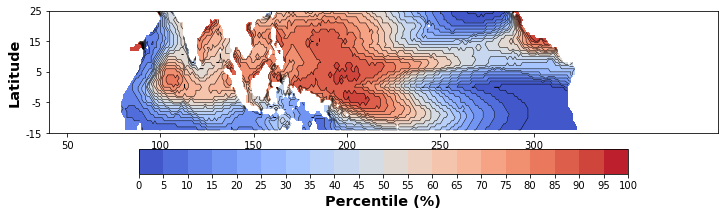

In [ ]:
sst_aso_qs= sst_qs[9]*5

# Define discrete color levels
levels = np.arange(0, 105, 5)  # Levels from 0 to 20

# Create the plot
fig, ax = plt.subplots(figsize = (12,3))
cbar = ax.contourf(sst_aso_qs, levels=levels, cmap='coolwarm')
contours = ax.contour(sst_aso_qs, levels=levels, colors='black', linewidths=0.5)
#plt.clabel(contours, inline=False, fontsize=8)

# Add a horizontal discrete colorbar
cbar_ax = fig.colorbar(cbar, ax=ax, orientation='horizontal', ticks=levels, pad=0.1)
cbar_ax.set_label('Percentile (%)')

#plt.title('ASO SST Distribution')
plt.yticks(np.linspace(0, 40, 5),['{:.0f}'.format(t) for t in np.linspace(25, -15, 5)])
plt.xticks(np.linspace(10, 260, 6), ['{:.0f}'.format(t) for t in np.linspace(50, 300, 6)])

plt.xlabel('Longitude')
plt.ylabel('Latitude')

plt.gca().invert_yaxis()


plt.show()


In [ ]:
sst_aso_anom = sst.sel(time = '2023-09').anom - sst.sel(time = '2023-09').ocean_mean
sst_aso_anom = sst_aso_anom.values[0]

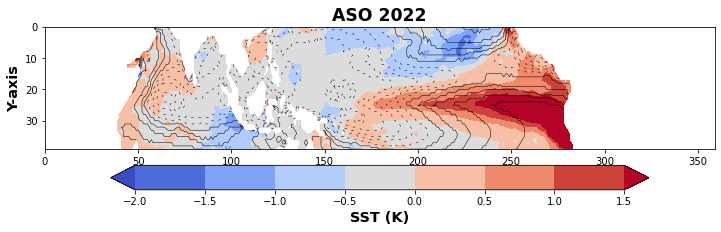

In [ ]:
sst_aso_qs= sst_qs[9]*5

# Define discrete color levels
levels = np.arange(0, 100, 10)  # Levels from 0 to 20

# Define line styles for contours
linestyles = ['solid' if level < 50 else (0, (5, 10)) for level in levels]


# Create the plot
fig, ax = plt.subplots(figsize = (12,3))
cbar = ax.contourf(sst_aso_anom, levels=np.arange(-2,2,0.5),
                   cmap='coolwarm', extend='both')
contours = ax.contour(sst_aso_qs, levels = levels,
                      linestyles = linestyles, colors='black', linewidths=0.5)
#plt.clabel(contours, inline=True, fontsize=8)



# Add a horizontal discrete colorbar
cbar_ax = fig.colorbar(cbar, ax=ax, orientation='horizontal', ticks=np.arange(-2,2,0.5), pad=0.1)
cbar_ax.set_label('SST (K)')

plt.title('ASO 2022')
plt.xlabel('X-axis')
#plt.xlim(40, 300)
plt.ylabel('Y-axis')
plt.gca().invert_yaxis()

plt.show()

In [ ]:

event_list = ['1991-09', '1987-09', '1982-09', '1997-09', '2015-09']

In [ ]:
sst_aso_anom_compound = np.zeros((len(event_list),sst_aso_qs.shape[0],sst_aso_qs.shape[1]))

for i,e in enumerate(event_list):
    sst_aso_anom_e = sst.sel(time = e).anom -sst.sel(time = e).ocean_mean
    sst_aso_anom_compound[i] = sst_aso_anom_e.values[0]
    
sst_aso_anom_compound = np.mean(sst_aso_anom_compound, axis = 0)

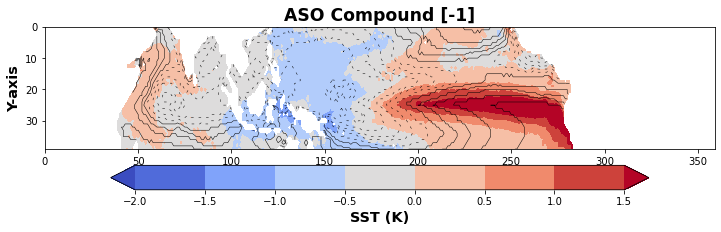

In [ ]:
sst_aso_qs= sst_qs[9]*5

# Define discrete color levels
levels = np.arange(0, 100, 10)  # Levels from 0 to 20

# Define line styles for contours
linestyles = ['solid' if level < 50 else (0, (5, 10)) for level in levels]


# Create the plot
fig, ax = plt.subplots(figsize = (12,3))
cbar = ax.contourf(sst_aso_anom_compound, levels=np.arange(-2,2,0.5), cmap='coolwarm', extend='both')
contours = ax.contour(sst_aso_qs, levels = levels,
                      linestyles = linestyles, colors='black', linewidths=0.5)#plt.clabel(contours, inline=True, fontsize=8)

# Add a horizontal discrete colorbar
cbar_ax = fig.colorbar(cbar, ax=ax, orientation='horizontal', ticks=np.arange(-2,2,0.5), pad=0.1)
cbar_ax.set_label('SST (K)')

plt.title('ASO Compound [-1]')
#plt.xlim(40, 300)
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.gca().invert_yaxis()

plt.show()

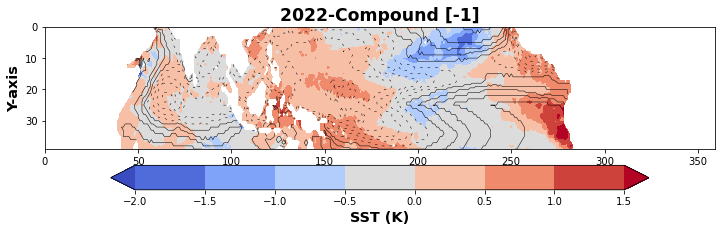

In [ ]:
sst_aso_qs= sst_qs[9]*5

# Define discrete color levels
levels = np.arange(0, 100, 10)  # Levels from 0 to 20

# Define line styles for contours
linestyles = ['solid' if level < 50 else (0, (5, 10)) for level in levels]


# Create the plot
fig, ax = plt.subplots(figsize = (12,3))
cbar = ax.contourf(sst_aso_anom - sst_aso_anom_compound, levels=np.arange(-2,2,0.5), cmap='coolwarm', extend='both')
contours = ax.contour(sst_aso_qs, levels = levels,
                      linestyles = linestyles, colors='black', linewidths=0.5)
#plt.clabel(contours, inline=True, fontsize=8)

# Add a horizontal discrete colorbar
cbar_ax = fig.colorbar(cbar, ax=ax, orientation='horizontal', ticks=np.arange(-2,2,0.5), pad=0.1)
cbar_ax.set_label('SST (K)')

plt.title('2022-Compound [-1]')
#plt.xlim(40, 300)
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.gca().invert_yaxis()

plt.show()

In [ ]:
# Add contours for NaN areas (continents)
nan_mask = np.isnan(ocean_mask)


ax.contour(nan_mask, levels=[0.5], colors='black', linewidths=1)


/tmp/ipykernel_821260/4120406756.py:5: UserWarning: No contour levels were found within the data range.
  ax.contour(nan_mask, levels=[0.5], colors='black', linewidths=1)


NameError: name 'tp_aso_anom' is not defined

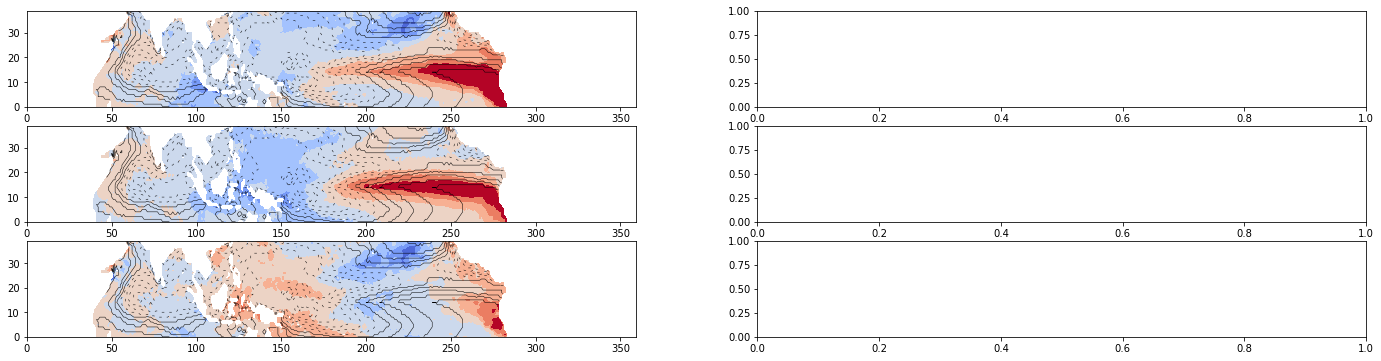

In [ ]:
import matplotlib.colors as colors

# Create the plot
fig, axes = plt.subplots(3,2, figsize = (24,6), sharex = False)

# define your scale, with white at zero
vmin = -2
vmax = 2
norm = colors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)


cbar = axes[0,0].contourf(sst_aso_anom[::-1,:], levels=np.arange(-2,2,0.5), norm = norm,  cmap='coolwarm', extend='both')
cbar = axes[1,0].contourf(sst_aso_anom_compound[::-1,:], levels=np.arange(-2,2,0.5), norm = norm, cmap='coolwarm', extend='both')
cbars = axes[2,0].contourf(sst_aso_anom[::-1,:] - sst_aso_anom_compound[::-1,:], levels=np.arange(-2,2,0.5), norm = norm, cmap='coolwarm', extend='both')

for ax in axes[:,0]:
    contours = ax.contour(sst_aso_qs[::-1,:], levels = levels,
                      linestyles = linestyles, colors='black', linewidths=0.5)


# define your scale, with white at zero
vmin = -10 
vmax = 10
norm = colors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

    
cbarp = axes[0,1].contourf(tp_aso_anom, levels=np.arange(-10,10,2.5), cmap='BrBG', norm = norm, extend='both')
cbar = axes[1,1].contourf(tp_aso_anom_compound, levels=np.arange(-10,10,2.5), cmap='BrBG', norm = norm, extend='both')

cbar = axes[2,1].contourf(tp_aso_anom - tp_aso_anom_compound, levels=np.arange(-10,10,2.5), cmap='BrBG', norm = norm, extend='both')



# Invert left y-axes
for ax in axes[:,0]:  # Iterate through all axes
    #ax.invert_yaxis()
    ax.set_xlim(30,290)
    ax.contour(ocean_mask, levels=[0.5], colors='black', linewidths=2)
    ax.axhline(16, c = 'k', linestyle = '--')



    
for ax in axes[:,1]:  # Iterate through all axes
    ax.set_xlim(7,115)
    ax.contour(ocean_mask2, levels=[0.5], colors='black', linewidths=2)
    ax.axhline(6, c = 'k', linestyle = '--')

    
for ax in axes.flat:
    ax.set_yticks([])
    ax.set_xticks([])
    ax.spines[:].set_linewidth(2)
    
    
    


plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.colors as colors

# Create the plot
fig, axes = plt.subplots(3, figsize = (12,6), sharex = False)

# define your scale, with white at zero
vmin = -2
vmax = 2
norm = colors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)


cbar = axes[0].contourf(sst_aso_anom[::-1,:], levels=np.arange(-2,2,0.5), norm = norm,  cmap='coolwarm', extend='both')
cbar = axes[1].contourf(sst_aso_anom_compound[::-1,:], levels=np.arange(-2,2,0.5), norm = norm, cmap='coolwarm', extend='both')
cbars = axes[2].contourf(sst_aso_anom[::-1,:] - sst_aso_anom_compound[::-1,:], levels=np.arange(-2,2,0.5), norm = norm, cmap='coolwarm', extend='both')

for ax in axes[:]:
    contours = ax.contour(sst_aso_qs[::-1,:], levels = levels,
                      linestyles = linestyles, colors='black', linewidths=0.5)


# Invert left y-axes
for ax in axes[:]:  # Iterate through all axes
    #ax.invert_yaxis()
    ax.set_xlim(30,290)
    ax.contour(ocean_mask, levels=[0.5], colors='black', linewidths=2)
    ax.axhline(15, c = 'k', linestyle = '--')


    
for ax in axes.flat:
    ax.set_yticks([])
    ax.set_xticks([])
    ax.spines[:].set_linewidth(2)
    
    
   
    ytick_position = [40,30,20,10, 0]
    ax.set_yticks(ticks = ytick_position,)
    ax.set_yticklabels(['25N', '15N', '5N', '5S', '15S'], fontsize=12)
    
xtick_position = [60, 120, 180, 240] 
xtick_labels = [ '60W', '120W', '180', '120E']
axes[2].set_xticks(ticks = xtick_position,)
axes[2].set_xticklabels(xtick_labels, fontsize = 12)


#plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.colors as colors

# Create the plot
fig, axes = plt.subplots(3, figsize = (12, 6), sharex = False)


# define your scale, with white at zero
vmin = -10 
vmax = 10
norm = colors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

    
cbarp = axes[0].contourf(tp_aso_anom, levels=np.arange(-10,10,2.5), cmap='BrBG', norm = norm, extend='both')
cbar = axes[1].contourf(tp_aso_anom_compound, levels=np.arange(-10,10,2.5), cmap='BrBG', norm = norm, extend='both')

cbar = axes[2].contourf(tp_aso_anom - tp_aso_anom_compound, levels=np.arange(-10,10,2.5), cmap='BrBG', norm = norm, extend='both')





    
for ax in axes[:]:  # Iterate through all axes
    ax.set_xlim(7,115)
    ax.contour(ocean_mask2, levels=[0.5], colors='black', linewidths=2)
    ax.axhline(6.5, c = 'k', linestyle = '--')

for ax in axes.flat:
    ax.set_yticks([])
    ax.set_xticks([])
    ax.spines[:].set_linewidth(2)
    
    
   
    ytick_position = [16,12,8,4, 0]
    ax.set_yticks(ticks = ytick_position,)
    ax.set_yticklabels(['25N', '15N', '5N', '5S', '15S'], fontsize=12)
    
xtick_position = [24, 48, 72, 96] 
xtick_labels = [ '60W', '120W', '180', '120E']
axes[2].set_xticks(ticks = xtick_position,)
axes[2].set_xticklabels(xtick_labels, fontsize = 12)
  
    


#plt.tight_layout()
plt.show()

In [ ]:
# Create the colorbar
a = plt.colorbar(cbarp, orientation='horizontal', label='Precipitation [mm/day]')

# Modify the font weight of the label
a.set_label('Precipitation [mm/day]', fontweight='normal', fontsize=16)  # Example font size and weight


In [ ]:
# Create the colorbar
b = plt.colorbar(cbars, orientation='horizontal', label='SST [K]')

# Modify the font weight of the label
b.set_label('SST [K]', fontweight='normal', fontsize=16)  # Example font size and weight


### tp

In [ ]:
fp = '/data/jmex/NOAA//latest/precip.mon.mean.nc'
tp = xr.open_dataset(fp).sel(lat = slice(-15,25), time = slice(None,None))
tp = tp.drop_vars(['time_bnds', 'lat_bnds', 'lon_bnds']).rename({'precip':'tp'})


In [ ]:
tp = tp.where(ocean_mask2)

In [ ]:
tp = tp.rolling(time = 3, center = True, min_periods = 1,).mean()

In [ ]:
tp_clim = tp.sel(time = slice('1991', '2020')).groupby('time.month').mean()
tp['anom'] = tp.tp.groupby('time.month') - tp_clim.tp

In [ ]:
weights = np.cos(np.deg2rad(tp.lat))
tp['ocean_mean'] = tp.anom.weighted(weights).mean(['lat', 'lon'])

In [ ]:
tp_aso_anom = tp.sel(time = '2023-09').anom - tp.sel(time = '2023-09').ocean_mean
tp_aso_anom = tp_aso_anom.values[0]

In [ ]:
sst_aso_qs= sst_qs[9]*5

# Define discrete color levels
levels = np.arange(0, 100, 10)  # Levels from 0 to 20

# Define line styles for contours
linestyles = ['solid' if level < 50 else (0, (5, 10)) for level in levels]


# Create the plot
fig, ax = plt.subplots(figsize = (12,3))
cbar = ax.contourf(tp_aso_anom, levels=np.arange(-10,10,0.5), cmap='BrBG', extend='both')
#contours = ax.contour(sst_aso_qs, levels = levels, 
 #                     linestyles = linestyles, colors='black', linewidths=0.5)
#plt.clabel(contours, inline=True, fontsize=8)
# Add a horizontal discrete colorbar
cbar_ax = fig.colorbar(cbar, ax=ax, orientation='horizontal', ticks=np.arange(-10,10,2), pad=0.1)
cbar_ax.set_label('tp (mm/day)')

plt.title('ASO 2023')
plt.xlabel('X-axis')
#plt.xlim(15, 115)
plt.ylabel('Y-axis')

plt.show()

In [ ]:

event_list = ['1991-09', '1987-09', '1982-09', '1997-09', '2015-09']

In [ ]:
tp_aso_anom_compound = np.zeros((len(event_list),tp.lat.shape[0],tp.lon.shape[0]))

for i,e in enumerate(event_list):
    tp_aso_anom_e = tp.sel(time = e).anom -tp.sel(time = e).ocean_mean
    tp_aso_anom_compound[i] = tp_aso_anom_e.values[0]
    
tp_aso_anom_compound = np.mean(tp_aso_anom_compound, axis = 0)

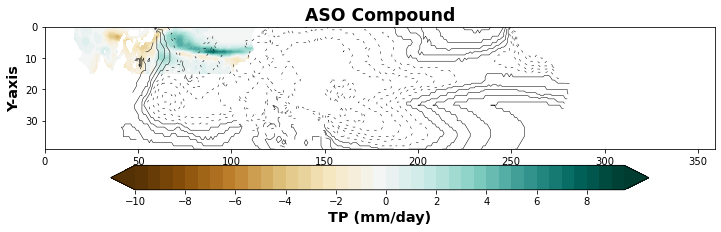

In [ ]:
sst_aso_qs= sst_qs[9]*5

# Define discrete color levels
levels = np.arange(0, 100, 10)  # Levels from 0 to 20

# Define line styles for contours
linestyles = ['solid' if level < 50 else (0, (5, 10)) for level in levels]


# Create the plot
fig, ax = plt.subplots(figsize = (12,3))
cbar = ax.contourf(tp_aso_anom_compound, levels=np.arange(-10,10,0.5), cmap='BrBG', extend='both')
contours = ax.contour(sst_aso_qs, levels = levels, 
                      linestyles = linestyles, colors='black', linewidths=0.5)#plt.clabel(contours, inline=True, fontsize=8)

# Add a horizontal discrete colorbar
cbar_ax = fig.colorbar(cbar, ax=ax, orientation='horizontal', ticks=np.arange(-10,10,2), pad=0.1)
cbar_ax.set_label('TP (mm/day)')

plt.title('ASO Compound')
#plt.xlim(15, 115)
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
#
plt.gca().invert_yaxis()

plt.show()

NameError: name 'tp_aso_anom' is not defined

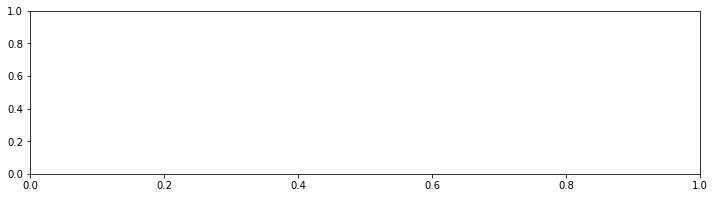

In [ ]:
sst_aso_qs= sst_qs[9]*5

# Define discrete color levels
levels = np.arange(0, 100, 10)  # Levels from 0 to 20

# Define line styles for contours
linestyles = ['solid' if level < 50 else (0, (5, 10)) for level in levels]


# Create the plot
fig, ax = plt.subplots(figsize = (12,3))

cbar = ax.contourf(tp_aso_anom - tp_aso_anom_compound, levels=np.arange(-10,10,0.5), cmap='BrBG', extend='both')
contours = ax.contour(sst_aso_qs, levels = levels, 
                      linestyles = linestyles, colors='black', linewidths=0.5)#plt.clabel(contours, inline=True, fontsize=8)

# Add a horizontal discrete colorbar
cbar_ax = fig.colorbar(cbar, ax=ax, orientation='horizontal', ticks=np.arange(-10,10,2), pad=0.1)
cbar_ax.set_label('TP (mm/day)')

plt.title('ASO 2023 - Compound')
plt.xlim(15, 115)
plt.xlabel('X-axis')
plt.ylabel('Y-axis')

plt.show()

In [ ]:
sst_aso_anom = sst.sel(time = '2023-09').anom - sst.sel(time = '2023-09').ocean_mean
sst_aso_anom = sst_aso_anom.values[0]

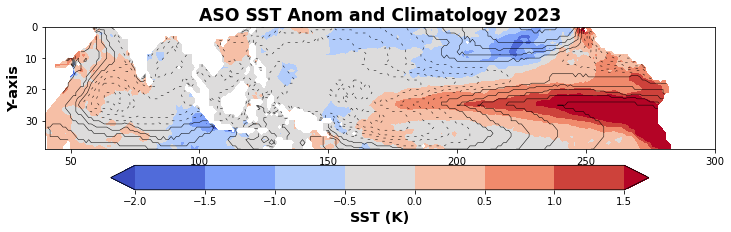

In [ ]:
sst_aso_qs= sst_qs[9]*5

# Define discrete color levels
levels = np.arange(0, 100, 10)  # Levels from 0 to 20

# Define line styles for contours
linestyles = ['solid' if level < 50 else (0, (5, 10)) for level in levels]


# Create the plot
fig, ax = plt.subplots(figsize = (12,3))
cbar = ax.contourf(sst_aso_anom, levels=np.arange(-2,2,0.5),
                   cmap='coolwarm', extend='both')
contours = ax.contour(sst_aso_qs, levels = levels,
                      linestyles = linestyles, colors='black', linewidths=0.5)
#plt.clabel(contours, inline=True, fontsize=8)



# Add a horizontal discrete colorbar
cbar_ax = fig.colorbar(cbar, ax=ax, orientation='horizontal', ticks=np.arange(-2,2,0.5), pad=0.1)
cbar_ax.set_label('SST (K)')

plt.title('ASO SST Anom and Climatology 2023')
plt.xlabel('X-axis')
plt.xlim(40, 300)
plt.ylabel('Y-axis')
plt.gca().invert_yaxis()

plt.show()